In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from pathlib import Path

In [5]:
# Leyendo datos
df = pd.read_csv('mobile-price/train.csv')
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


# Exploración inicial del dataset

Este dataset contiene información técnica sobre teléfonos móviles.  
El objetivo es **clasificar el rango de precio del dispositivo**.

Variable objetivo:

- `price_range`

Clases:

- 0 → Low cost
- 1 → Medium cost
- 2 → High cost
- 3 → Very high cost

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_screen   2000

In [8]:
df.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


# Distribución de la variable objetivo

Antes de entrenar modelos es importante verificar si existe desbalance entre clases.

In [9]:
df["price_range"].value_counts().sort_index()

price_range
0    500
1    500
2    500
3    500
Name: count, dtype: int64

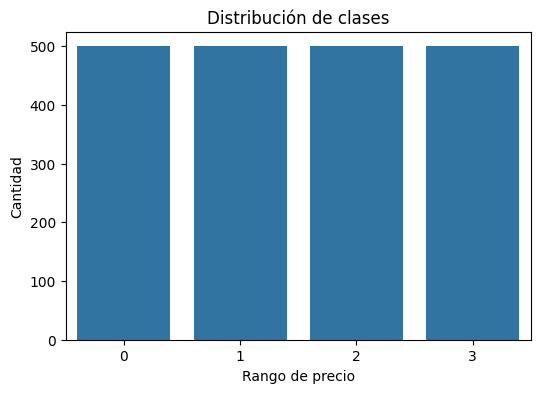

In [16]:
plt.figure(figsize=(6,4))

sns.countplot(x="price_range", data=df)

plt.title("Distribución de clases")
plt.xlabel("Rango de precio")
plt.ylabel("Cantidad")

plt.show()

# Distribución de algunas variables numéricas

Se analizarán algunas variables relevantes para observar su distribución.

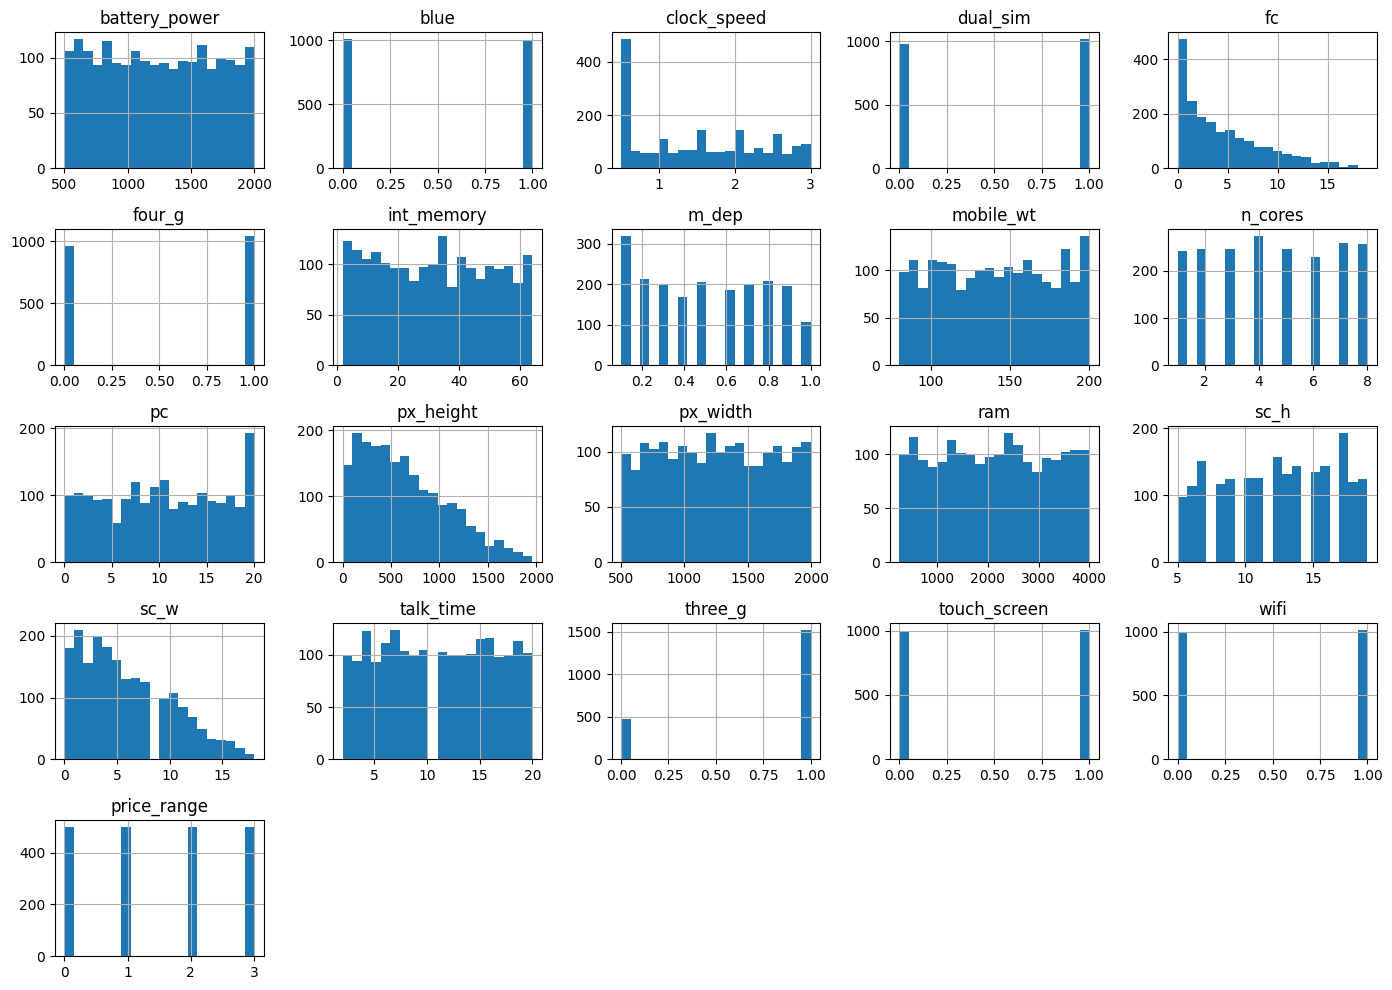

In [17]:
df.hist(figsize=(14,10), bins=20)

plt.tight_layout()
plt.show()

# Correlación entre variables

La matriz de correlación permite identificar relaciones entre variables.

También permite detectar variables que podrían tener mayor influencia en la variable objetivo.

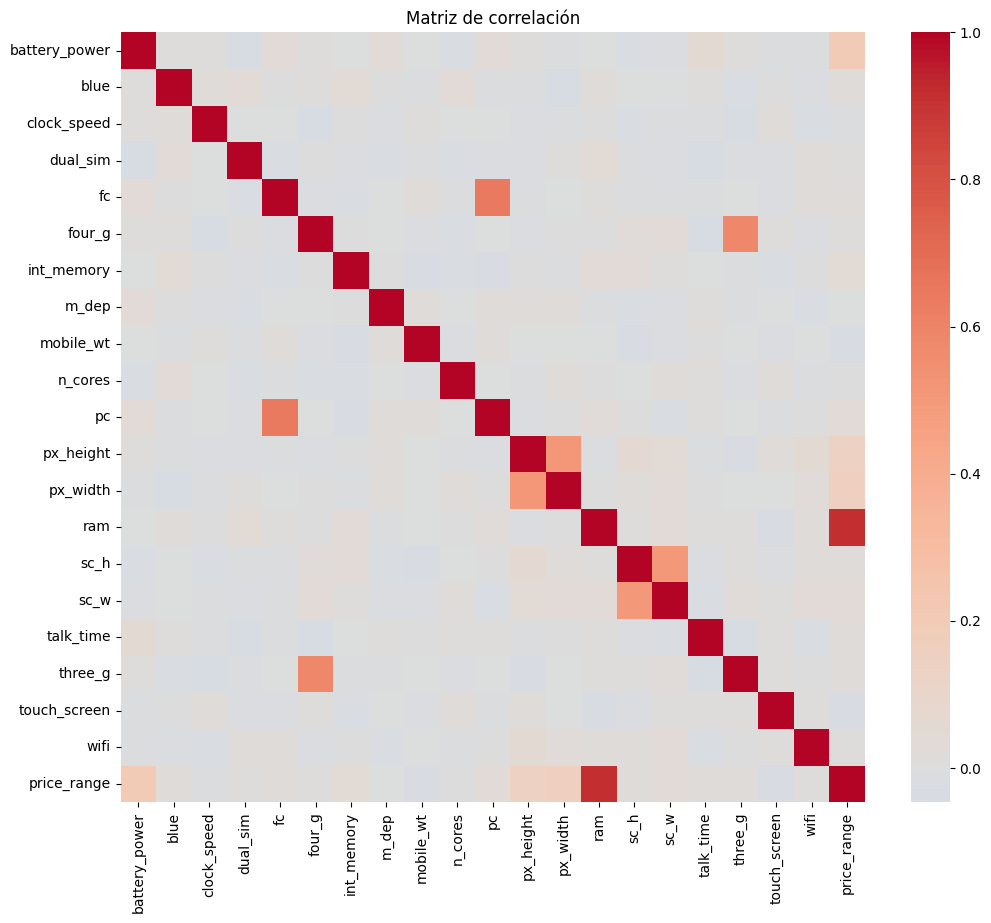

In [18]:
corr = df.corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de correlación")
plt.show()

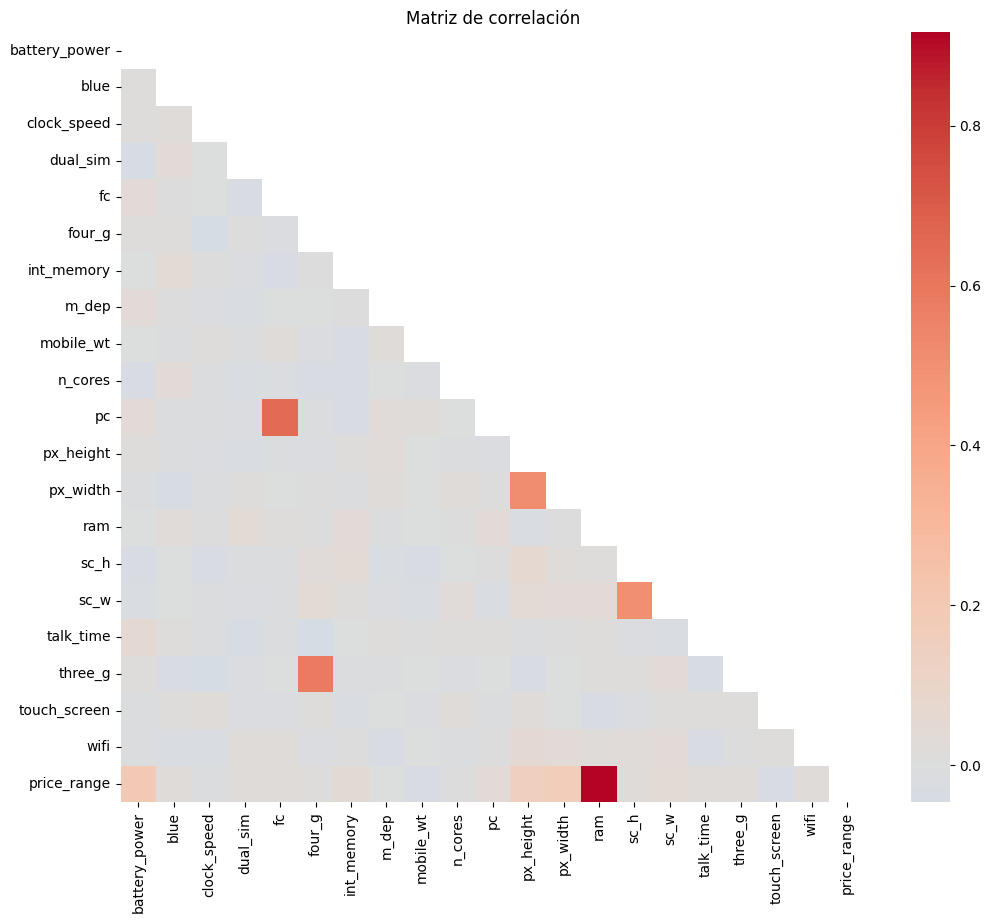

In [24]:
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de correlación")
plt.show()

# Correlación con la variable objetivo

Se observará qué variables tienen mayor relación con el rango de precio.

In [20]:
corr_target = corr["price_range"].sort_values(ascending=False)

corr_target

price_range      1.000000
ram              0.917046
battery_power    0.200723
px_width         0.165818
px_height        0.148858
int_memory       0.044435
sc_w             0.038711
pc               0.033599
three_g          0.023611
sc_h             0.022986
fc               0.021998
talk_time        0.021859
blue             0.020573
wifi             0.018785
dual_sim         0.017444
four_g           0.014772
n_cores          0.004399
m_dep            0.000853
clock_speed     -0.006606
mobile_wt       -0.030302
touch_screen    -0.030411
Name: price_range, dtype: float64

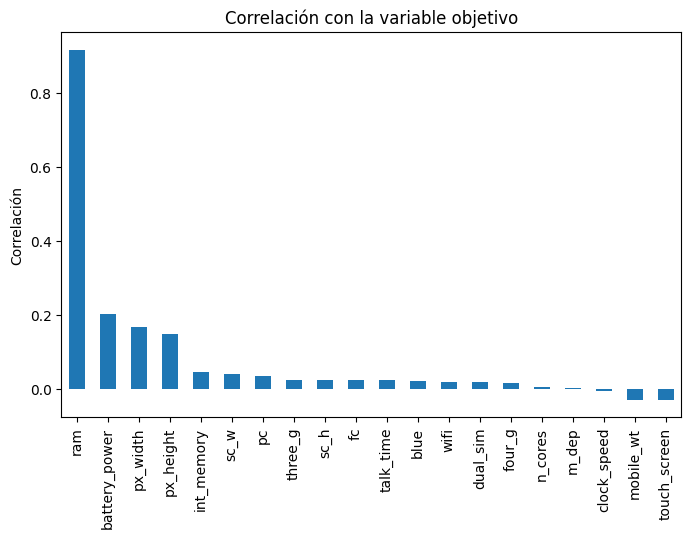

In [21]:
corr_target.drop("price_range").plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Correlación con la variable objetivo")
plt.ylabel("Correlación")

plt.show()

## Dividiendo conjunto de datos

In [26]:
# División de datos

X = df.drop(columns=["price_range"])
y = df["price_range"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (1600, 20) (1600,)
Test shape: (400, 20) (400,)


In [28]:
# Guardando datos

out_dir = Path("mobile-price/processed")
out_dir.mkdir(parents=True, exist_ok=True)

train_df = X_train.copy()
train_df["price_range"] = y_train.values

test_df = X_test.copy()
test_df["price_range"] = y_test.values

train_path = out_dir / "train_split.csv"
test_path = out_dir / "test_split.csv"

train_df.to_csv(train_path, index=False)
test_df.to_csv(test_path, index=False)

print("Saved:", train_path)
print("Saved:", test_path)

Saved: mobile-price/processed/train_split.csv
Saved: mobile-price/processed/test_split.csv


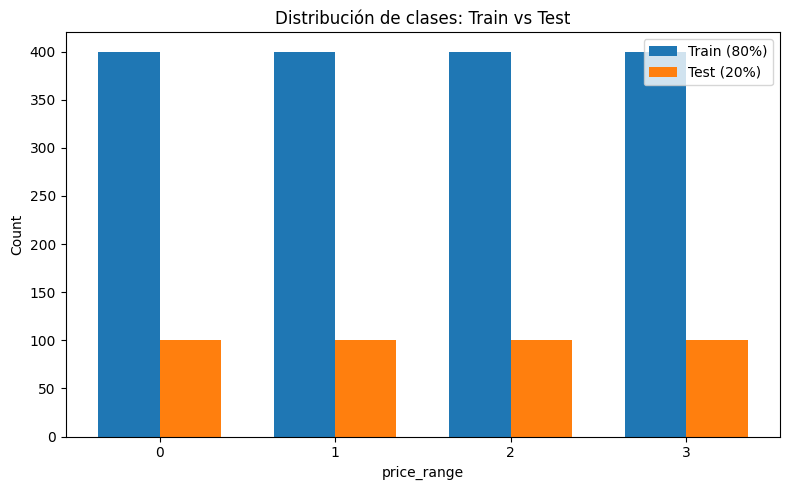

In [29]:
classes = sorted(y.unique())

train_counts = y_train.value_counts().reindex(classes, fill_value=0)
test_counts = y_test.value_counts().reindex(classes, fill_value=0)

x = np.arange(len(classes))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, train_counts.values, width, label="Train (80%)")
plt.bar(x + width/2, test_counts.values, width, label="Test (20%)")

plt.xticks(x, classes)
plt.xlabel("price_range")
plt.ylabel("Count")
plt.title("Distribución de clases: Train vs Test")
plt.legend()
plt.tight_layout()
plt.show()